# Shortest Paths and Dijkstra's Algorithm

We start by defining a digraph `D` that we can work with throughout the remainder of this notebook.

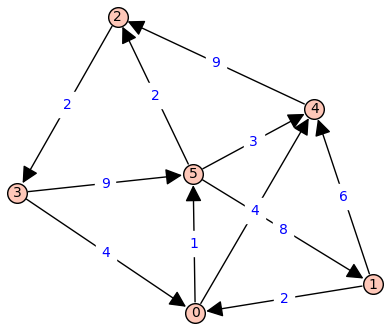

In [23]:
G=graphs.RandomGNP(6,0.8)

while True:
    D=DiGraph()
    for e in G.edges():
        e=(e[0],e[1],randint(1,9))
        if randint(0,1):
            D.add_edge(e[0],e[1],e[2])
        else:
            D.add_edge(e[1],e[0],e[2])
    if D.is_strongly_connected():
        break

D.show(edge_labels=True,layout='spring',save_pos=True)

Using the built-in `distance` and `shortest_path` functions, we can find the distance and a shortest path between any pair of vertices we like in the digraph `D`.

In [74]:
print(D.distance(0,2))

2


In [72]:
print(D.shortest_path(0,2))

[0, 4, 2]


### Your Turn!

Find a shortest path between the vertices 0 and 4 in `D`, and find the length of this shortest path.

In [ ]:
# YOUR CODE HERE

# Dijkstra's Algorithm

Now we implement our own version of Dijkstra's algorithm, which finds a shortest directed path from a specified vertex to every other vertex in a given digraph.

In [64]:
def Dijkstra(D,r):  # Finds a shortest directed path from vertex r to every other vertex in D.
    
    n=D.order()

    Distance={r:0}  # A dictionary that will hold the current distance to each vertex.  We initially set the distance to r to 0.
    Path={}         # A dictionary that will hold the current shortest path to each vertex.
    for v in D.vertices():
        Path[v]=[r]         # The path to every vertex v must start with r.
        if not v==r: 
            Distance[v]=oo  # Initialize the distance to every vertex v (other than r) to infinity, which is denoted oo in Sage.

    S=[r]   # This is the set of vertices to which we currently know a shortest path.
    SComplement=D.vertices().copy()
    SComplement.remove(r)  # SComplement is the complement of S, i.e., the set of vertices to which we do not currently know a shortest path.
    print(SComplement)
    F=[]  # The set of edges that will form a directed spanning tree containing shortest directed paths from r to every vertex of the digraph.

    scan=r  # The vertex that we scan from.  We start by scanning from r.

    while len(S)<n:  # Repeat until S contains all n vertices of D.
        
        for e in D.edges():
            if e[0]==scan:  # Run through all directed edges that start from the vertex we are scanning from.
                if Distance[scan]+e[2]<Distance[e[1]]:  # If the edge e gets us to the other end e[1] in less distance than the current shortest distance in our dictionary,
                    Distance[e[1]]=Distance[scan]+e[2]  # then we update the distance and the path to e[1]
                    Path[e[1]]=Path[scan]+[e[1]]
        
        print(Distance)  # Print the current dictionary of distances.
        print(Path)      # Print the current dictionary of paths.

        # Now we want to add a vertex to S, and scan from that new vertex at the next step.  We find a vertex not in S to which the current distance is shortest.
        min_distance=oo
        for v in SComplement:
            if Distance[v]<min_distance:
                min_distance=Distance[v]
                scan=v
                
        if min_distance==oo:  # If the distance to every vertex not in S is infinity, then we cannot reach the vertices outside of S, so we return the current distances and paths.
            return(F,Distance,Path)
            
        SComplement.remove(scan)
        S.append(scan)
        F.append((Path[scan][-2],Path[scan][-1]))
        
    return(F,Distance,Path)

In [65]:
Dijkstra(D,0)

[1, 2, 3, 4, 5]
{0: 0, 1: +Infinity, 2: +Infinity, 3: +Infinity, 4: 4, 5: 1}
{0: [0], 1: [0], 2: [0], 3: [0], 4: [0, 4], 5: [0, 5]}
{0: 0, 1: 9, 2: 3, 3: +Infinity, 4: 4, 5: 1}
{0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0], 4: [0, 4], 5: [0, 5]}
{0: 0, 1: 9, 2: 3, 3: 5, 4: 4, 5: 1}
{0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0, 5, 2, 3], 4: [0, 4], 5: [0, 5]}
{0: 0, 1: 9, 2: 3, 3: 5, 4: 4, 5: 1}
{0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0, 5, 2, 3], 4: [0, 4], 5: [0, 5]}
{0: 0, 1: 9, 2: 3, 3: 5, 4: 4, 5: 1}
{0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0, 5, 2, 3], 4: [0, 4], 5: [0, 5]}


([(0, 5), (5, 2), (0, 4), (2, 3), (5, 1)],
 {0: 0, 1: 9, 2: 3, 3: 5, 4: 4, 5: 1},
 {0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0, 5, 2, 3], 4: [0, 4], 5: [0, 5]})

In [68]:
def color_special_edges_red(G,special_edges):  # Produces a drawing of the graph/digraph G with the edges in special_edges coloured red
    edge_colors={}
    edge_colors['red']=special_edges
    plt=G.graphplot(edge_colors=edge_colors,edge_labels=True)
    plt.show()

[1, 2, 3, 4, 5]
{0: 0, 1: +Infinity, 2: +Infinity, 3: +Infinity, 4: 4, 5: 1}
{0: [0], 1: [0], 2: [0], 3: [0], 4: [0, 4], 5: [0, 5]}
{0: 0, 1: 9, 2: 3, 3: +Infinity, 4: 4, 5: 1}
{0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0], 4: [0, 4], 5: [0, 5]}
{0: 0, 1: 9, 2: 3, 3: 5, 4: 4, 5: 1}
{0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0, 5, 2, 3], 4: [0, 4], 5: [0, 5]}
{0: 0, 1: 9, 2: 3, 3: 5, 4: 4, 5: 1}
{0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0, 5, 2, 3], 4: [0, 4], 5: [0, 5]}
{0: 0, 1: 9, 2: 3, 3: 5, 4: 4, 5: 1}
{0: [0], 1: [0, 5, 1], 2: [0, 5, 2], 3: [0, 5, 2, 3], 4: [0, 4], 5: [0, 5]}


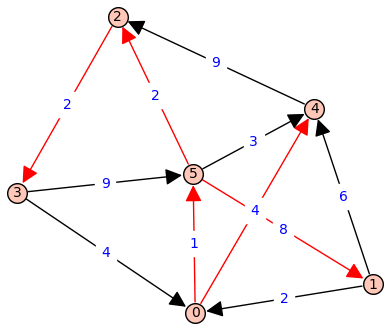

In [67]:
color_special_edges_red(D,Dijkstra(D,0)[0])